<a href="https://colab.research.google.com/github/c0b23144/oxford_pet_diffusion_generate/blob/main/oxford_pet_generate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -q torch torchvision

In [2]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

transform = transforms.Compose([
    transforms.Resize(
        (128, 128),
        interpolation=InterpolationMode.BICUBIC
        ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

print("画像枚数:", len(dataset))

100%|██████████| 792M/792M [00:33<00:00, 23.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.7MB/s]


画像枚数: 3680


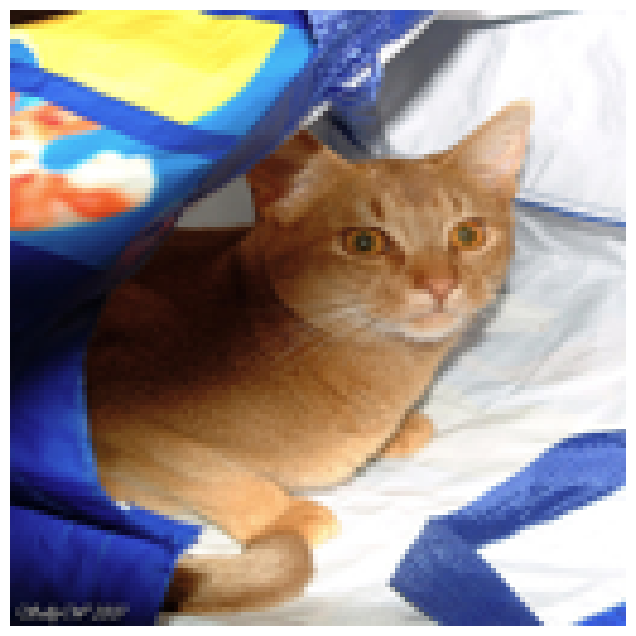

ラベル: 0


In [3]:
import matplotlib.pyplot as plt

image, label = dataset[0]

# -1～1 ⇒ 0～1に戻す
image = image * 0.5 + 0.5

plt.figure(figsize=(8, 8))
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()

print("ラベル:", label)

In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# diffusionのステップ数
T = 1000

# ノイズの強さ
beta = torch.linspace(
    0.0001,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def add_noise(x, t):
    # ランダムなノイズ
    noise = torch.randn_like(x)

    # その時点での画像の残り具合
    a = alpha_bar[t]
    a = a.view(-1, 1, 1, 1)

    # 画像にノイズを加える
    noisy_image = (
        torch.sqrt(a) * x
        + torch.sqrt(1 - a) * noise
    )

    return noisy_image, noise


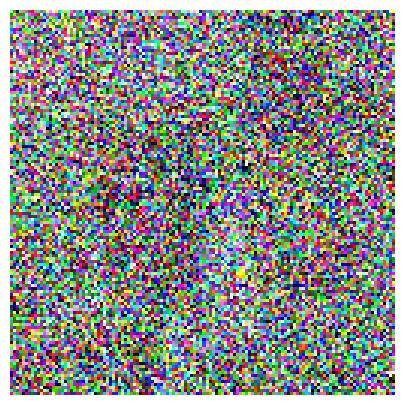

In [5]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

images, labels = next(iter(loader))
images = images.to(device)

# 500段階目までノイズを加える
# 16枚全部を「500段階目」のノイズ状態にする
# 16枚はbatch_size

t = torch.full(
    (images.shape[0],),
    500,
    device = device,
    dtype=torch.long
)

noisy_images, noise = add_noise(images, t)

# 表示
image = noisy_images[0]
image = image * 0.5 + 0.5
image = image.clamp(0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(image.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

In [ ]:
import math
import torch.nn as nn

# 時間tをベクトルに変換
class TimeEmbedding(nn.Module):

    def __init__(self, dim):
        super().__init__()

        self.dim = dim

    def forward(self. t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)

        emb = torch.exp(
            torch.arange(
                half,
                device=t.device
            ) * -emb
        )

        # 64個のsin + 64個のcos = dim(128)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat(
            (emb.sin(), emb.cos()),
            dim=1
        )

        return emb

# 畳み込みブロック
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=1
        )

        self.time = nn.Linear(
            time_dim,
            out_channels
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.act = nn.SiLU()

    def forward(self, x, t):
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.act(x)

        # 時間情報を画像に追加
        time = self.time(t)
        time = time[:, :, None, None]

        x = x + time

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.act(x)

        return x

# diffusion用 Unet
class Unet(nn.Module):
    def __init__(self):
        super().__init__()
        time_dim = 128

        # 時間情報
        self.time_embedding = TimeEmbedding(
            time_dim
        )

        # Down
        self.down1 = Block(
            3,
            64,
            time_dim
        )
